# Hole Similarity Research

Explore **how golf holes compare to each other**, using features engineered from
the pipeline's normalized 3D point clouds (30 courses, 540 holes).

### What the data represents
Each hole was sampled into a dense labeled point cloud (fairway / green / tee /
bunker / water / trees / cartpath / sand / rough), aggregated into **one feature
row per hole** (`hole_features.parquet`, 540 × ~90).

### The tee-relative coordinate system
Every hole is re-expressed so it is directly comparable to every other hole:
- **tee = origin** `(0, 0, 0)`, **green along `+Y`**,
- **`x < 0` is left, `x > 0` is right** of the tee→green line,
- **`z` is elevation relative to the tee** (`z_rel = elevation − tee_elevation`).

### Reading `rough_pct`
Points cover the whole ~200 m-wide **corridor** (100 m buffer each side), so
`rough_pct` is mostly background ("not covered by another feature"), not penal
rough. Hazard percentages are the discriminating signals.

### v1 vs v2
- **v1** = standardized features → unweighted nearest neighbors. Simple, but
  length is just one feature among ~86, so a 400 m hole can match a 300 m hole if
  shape/hazards line up.
- **v2 (length-aware)** = up-weight length-related features **and** apply a
  *length guard* that filters out candidates whose length differs too much. This
  is the recommended mode for presentation (see section 7).

## 0. Data source — local pipeline output or downloaded Hugging Face artifact

This notebook runs against **either** source, selected by `ARTIFACT_ROOT` below:

1. **Local pipeline output** — `courses/_index/` (you ran `python -m pipeline.modeling all`).
   Every hole has a compact point cloud, so all visual comparisons work.
2. **Downloaded Hugging Face artifact** — a folder pulled with:
   ```
   hf download davishelman/golf-data-research-artifacts --repo-type dataset \
       --local-dir golf-data-research-artifacts
   ```
   The tabular/similarity/cluster sections fully reproduce. Visual comparisons
   only render for holes whose compact point cloud is included — **all** holes in
   the *full* tier, a **curated subset** (the anchor hole + its neighbours) in the
   *lite* tier.

Leave `ARTIFACT_ROOT = None` to auto-detect (prefers local `courses/_index`, then
a downloaded artifact folder), or set it explicitly in the next cell.

In [1]:
from pathlib import Path

# --- Choose your data source -------------------------------------------------
# Option A: local generated pipeline data
# ARTIFACT_ROOT = Path('..') / 'courses' / '_index'

# Option B: downloaded Hugging Face artifact
# ARTIFACT_ROOT = Path('golf-data-research-artifacts')
# ARTIFACT_ROOT = Path(r'C:\Users\dhelm\projects\hf-test-project\golf-data-research-artifacts')

ARTIFACT_ROOT = None  # None = auto-detect (local courses/_index, then artifact folders)

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')  # so `import pipeline` works from notebooks/
from pipeline.modeling.similarity import (
    feature_columns, feature_summary, build_feature_matrix,
    run_pca, cluster_kmeans, nearest_neighbor_table, similar_holes,
    similar_holes_mode, SIMILARITY_MODES,
)
from pipeline.modeling.artifact_loader import load_modeling_artifacts
from pipeline.modeling.visual_compare import (
    plot_hole_comparison, save_hole_comparison, available_compact_ids,
)

# Load tables from whichever source ARTIFACT_ROOT resolves to (see the config cell).
art = load_modeling_artifacts(ARTIFACT_ROOT)
print(f"Using artifact source: {art['label']}")

feat = art['features']
clusters = art['clusters']
examples = art['similarity_v1']          # v1 nearest-hole table (may be None)
COMPACT_DIR = art['compact_dir']         # HF artifact compact dir, else None
COURSES_ROOT = art['courses_root'] if art['courses_root'] is not None else (Path('..') / 'courses')

cols = feature_columns(feat)
X, imputer, scaler = build_feature_matrix(feat, cols)   # v1 (unweighted) matrix
LEN_OF = feat.set_index('hole_id')['hole_length_m']
m = feat.merge(clusters[['hole_id','kmeans_cluster','agg_cluster','pca_1','pca_2']], on='hole_id')
print(f'{len(feat)} holes | {feat["course_slug"].nunique()} courses | {len(cols)} model features')


def viz_compare(ids, titles=None, color_by='label', max_points=30000, save_to=None):
    """Side-by-side hole comparison that works for both data sources.

    Local mode draws from the full ``courses/`` tree (every hole available). HF
    artifact mode draws from the shipped ``point_clouds/compact/`` folder, which
    in the *lite* tier holds only a curated subset -- missing holes are skipped
    with a friendly message instead of crashing.
    """
    if COMPACT_DIR is not None:
        avail = available_compact_ids(COMPACT_DIR)
        if not ids or ids[0] not in avail:
            print(f"[viz] query hole {ids[0] if ids else None!r} has no compact point "
                  f"cloud in this artifact (lite ships a curated subset); skipping. "
                  f"Use the full local pipeline for arbitrary holes.")
            return None
        keep = [h for h in ids if h in avail]
        missing = [h for h in ids if h not in avail]
        if len(keep) < 2:
            print(f"[viz] need >=2 holes with compact clouds; have {keep}; skipping.")
            return None
        if missing:
            print(f"[viz] note: {missing} not in this artifact; plotting {keep}.")
        ktitles = [t for h, t in zip(ids, titles) if h in avail] if titles else None
        src_root, kw = None, dict(compact_dir=COMPACT_DIR)
    else:
        keep, ktitles, src_root, kw = list(ids), titles, COURSES_ROOT, {}
    try:
        if save_to is not None:
            return save_hole_comparison(src_root, keep, save_to, titles=ktitles,
                                        color_by=color_by, max_points=max_points, **kw)
        return plot_hole_comparison(src_root, keep, titles=ktitles,
                                    color_by=color_by, max_points=max_points, **kw)
    except FileNotFoundError as exc:
        print(f"[viz] {exc}")
        return None

Using artifact source: local ../courses/_index


540 holes | 30 courses | 86 model features


## 1. Data overview

In [3]:
print('Holes:', len(feat), '| Courses:', feat['course_slug'].nunique())
display(feat['par'].value_counts().sort_index().rename('holes').to_frame())
feat[['hole_length_m','fairway_pct','rough_pct','bunker_pct','water_pct',
      'trees_pct','dogleg_score','tee_to_green_elevation_change']].describe().round(3)

Holes: 540 | Courses: 30


,holes
par,
3,111
4,308
5,121


,hole_length_m,fairway_pct,rough_pct,bunker_pct,water_pct,trees_pct,dogleg_score,tee_to_green_elevation_change
count,540.000,540.000,540.000,540.000,540.000,540.000,478.000,540.000
mean,368.760,0.056,0.831,0.008,0.047,0.043,0.121,-1.185
std,114.469,0.034,0.128,0.010,0.079,0.095,0.172,6.415
min,69.740,0.000,0.314,0.000,0.000,0.000,0.006,-35.540
25%,320.293,0.039,0.767,0.003,0.000,0.000,0.048,-3.186
50%,395.518,0.054,0.878,0.005,0.010,0.000,0.086,-0.486
75%,446.063,0.071,0.921,0.009,0.061,0.025,0.139,1.002
max,595.933,0.234,1.000,0.104,0.492,0.572,2.355,21.862


## 2. Validation

Engineered features are `NaN` when undefined for a hole (a par-3 has no drive
zone) and are **median-imputed** before modeling. See where the gaps are.

In [4]:
fs = feature_summary(feat, cols)
display(fs.head(12))
missing_dogleg = feat[feat['dogleg_score'].isna()][['hole_id','par','hole_length_m']]
print(f'{len(missing_dogleg)} holes missing dogleg_score (par-3s / sparse fairway).')

,column,dtype,n_missing,pct_missing
0,fairway_centerline_shift,float64,77,0.1426
1,fairway_width_drive_zone,float64,69,0.1278
2,dogleg_score,float64,62,0.1148
3,fairway_width_approach_zone,float64,50,0.0926
4,green_relative_elevation,float64,21,0.0389
5,drive_bunker_right_pct,float64,2,0.0037
6,drive_zone_trees_pct,float64,2,0.0037
7,drive_zone_sand_pct,float64,2,0.0037
8,drive_bunker_left_pct,float64,2,0.0037
9,drive_water_left_pct,float64,2,0.0037


62 holes missing dogleg_score (par-3s / sparse fairway).


## 3. PCA — how much structure is in 2D?
PCA is only a **2D projection**; clustering/NN run on the full standardized space.

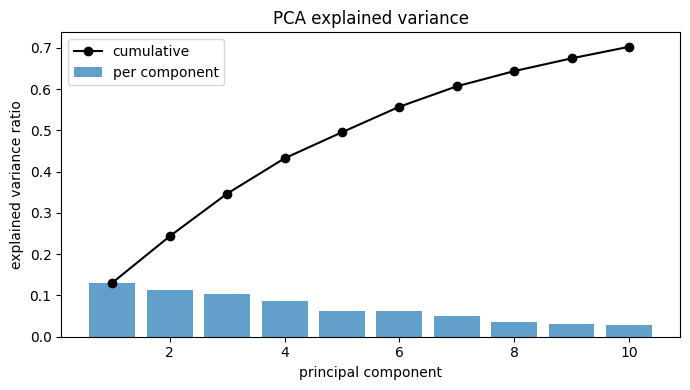

PC1+PC2 explain 24.3% of total variance


In [5]:
_, pca10 = run_pca(X, n_components=10)
evr = pca10.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(evr) + 1), evr, alpha=0.7, label='per component')
ax.plot(range(1, len(evr) + 1), np.cumsum(evr), 'o-', color='black', label='cumulative')
ax.set_xlabel('principal component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA explained variance'); ax.legend(); plt.tight_layout(); plt.show()
print('PC1+PC2 explain {:.1%} of total variance'.format(evr[:2].sum()))

## 4. Clusters and profiles

In [6]:
def cluster_profile(m, col='kmeans_cluster'):
    g = m.groupby(col)
    return pd.DataFrame({
        'size': g.size(), 'mean_par': g['par'].mean(), 'mean_len': g['hole_length_m'].mean(),
        'fairway': g['fairway_pct'].mean(), 'rough': g['rough_pct'].mean(),
        'trees': g['trees_pct'].mean(), 'water': g['water_pct'].mean(),
        'bunker': g['bunker_pct'].mean(), 'dogleg': g['dogleg_score'].mean(),
    })

prof = cluster_profile(m)
prof.round(3)

,size,mean_par,mean_len,fairway,rough,trees,water,bunker,dogleg
kmeans_cluster,,,,,,,,,
0,244,4.287,422.248,0.062,0.874,0.018,0.028,0.007,0.108
1,44,3.932,350.349,0.083,0.566,0.308,0.023,0.008,0.181
2,91,3.077,186.169,0.016,0.903,0.022,0.035,0.006,0.067
3,62,4.161,379.848,0.058,0.691,0.014,0.215,0.006,0.201
4,34,4.118,388.703,0.063,0.894,0.020,0.007,0.007,0.099
5,11,4.091,405.264,0.051,0.828,0.000,0.055,0.056,0.151
6,3,4.333,451.100,0.059,0.885,0.000,0.005,0.008,0.164
7,51,4.216,415.052,0.067,0.847,0.039,0.009,0.008,0.105


**Cluster sizes & stability.** Very small clusters (here the smallest has
~3 holes) should be read as **outlier-style groups, not stable design
categories**. We keep `k=8` for now.

### Suggested cluster names
A light heuristic labels each cluster from its **median-relative** profile.
**These are heuristic discussion labels, not an official taxonomy.**

In [7]:
def name_clusters(prof):
    med = prof.median(numeric_only=True)
    haz_map = {'tree_lined': 'trees', 'water_heavy': 'water', 'bunker_heavy': 'bunker'}
    names = {}
    for cid, r in prof.iterrows():
        if r['mean_par'] < 3.5:
            base = 'short_par_3'
        elif r['mean_par'] >= 4.6:
            base = 'long_par_5'
        elif r['mean_len'] >= med['mean_len']:
            base = 'long_standard_par_4'
        else:
            base = 'standard_par_4'
        scored = {lab: (r[c] / med[c] if med[c] > 0 else 0.0) for lab, c in haz_map.items()}
        top_lab, top_ratio = max(scored.items(), key=lambda kv: kv[1])
        if top_ratio >= 1.3:
            mod = top_lab
        elif med['dogleg'] > 0 and r['dogleg'] >= 1.3 * med['dogleg']:
            mod = 'dogleg'
        else:
            mod = 'open_low_hazard'
        names[cid] = f'{base}__{mod}'
    return names

cluster_names = name_clusters(prof)
named = prof.copy()
named.insert(0, 'suggested_name', [cluster_names[c] for c in named.index])
named.round(3)

,suggested_name,size,mean_par,mean_len,fairway,rough,trees,water,bunker,dogleg
kmeans_cluster,,,,,,,,,,
0,long_standard_par_4__open_low_hazard,244,4.287,422.248,0.062,0.874,0.018,0.028,0.007,0.108
1,standard_par_4__tree_lined,44,3.932,350.349,0.083,0.566,0.308,0.023,0.008,0.181
2,short_par_3__water_heavy,91,3.077,186.169,0.016,0.903,0.022,0.035,0.006,0.067
3,standard_par_4__water_heavy,62,4.161,379.848,0.058,0.691,0.014,0.215,0.006,0.201
4,standard_par_4__open_low_hazard,34,4.118,388.703,0.063,0.894,0.020,0.007,0.007,0.099
5,long_standard_par_4__bunker_heavy,11,4.091,405.264,0.051,0.828,0.000,0.055,0.056,0.151
6,long_standard_par_4__open_low_hazard,3,4.333,451.100,0.059,0.885,0.000,0.005,0.008,0.164
7,long_standard_par_4__tree_lined,51,4.216,415.052,0.067,0.847,0.039,0.009,0.008,0.105


In [8]:
display(pd.crosstab(m['kmeans_cluster'], m['par']))
display(m.groupby('kmeans_cluster')['course_slug'].agg(
    distinct_courses='nunique',
    top_course=lambda s: s.value_counts().index[0],
    top_course_n=lambda s: int(s.value_counts().iloc[0])))

par,3,4,5
kmeans_cluster,,,
0,0,174,70
1,11,25,8
2,84,7,0
3,9,34,19
4,3,24,7
5,0,10,1
6,0,2,1
7,4,32,15


,distinct_courses,top_course,top_course_n
kmeans_cluster,,,
0,30,detroit_golf_club,17
1,10,augusta_national,16
2,27,harbour_town_golf_links,6
3,17,trump_national_doral_blue_monster,10
4,11,riviera_country_club,8
5,5,harbour_town_golf_links,5
6,2,bay_hill_club_and_lodge,2
7,14,pebble_beach_golf_links,7


## 5. Visualizations

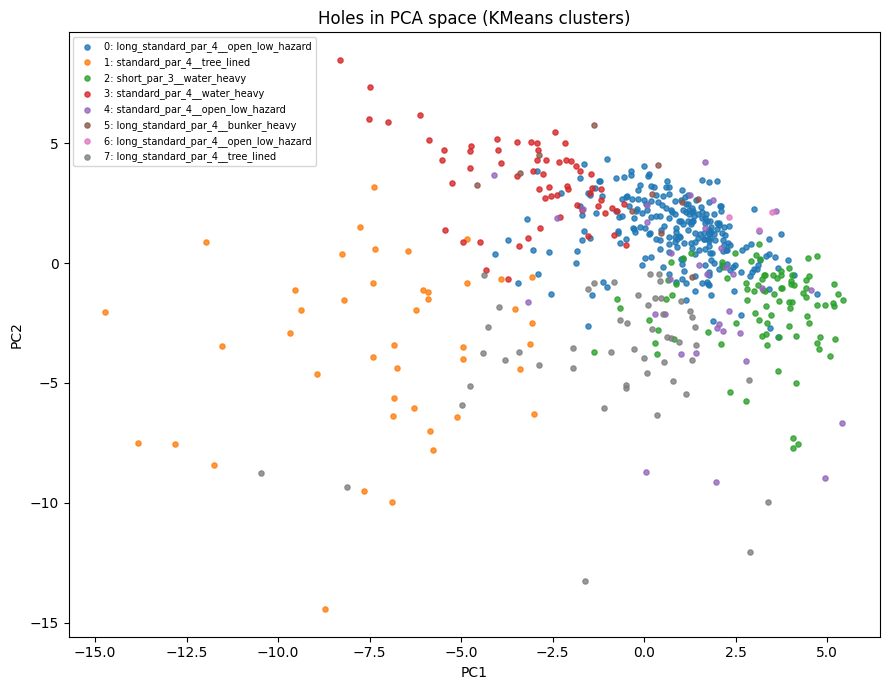

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
for cid, g in m.groupby('kmeans_cluster'):
    ax.scatter(g['pca_1'], g['pca_2'], s=14, alpha=0.8, label=f'{cid}: {cluster_names[cid]}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Holes in PCA space (KMeans clusters)')
ax.legend(fontsize=7, loc='best'); plt.tight_layout(); plt.show()

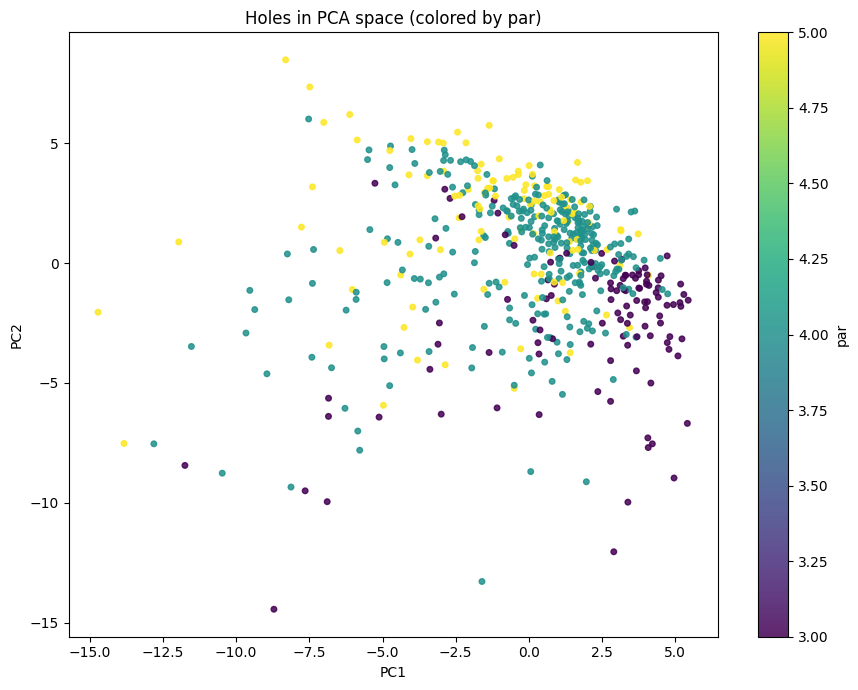

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(m['pca_1'], m['pca_2'], c=m['par'], cmap='viridis', s=16, alpha=0.85)
plt.colorbar(sc, label='par'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Holes in PCA space (colored by par)'); plt.tight_layout(); plt.show()

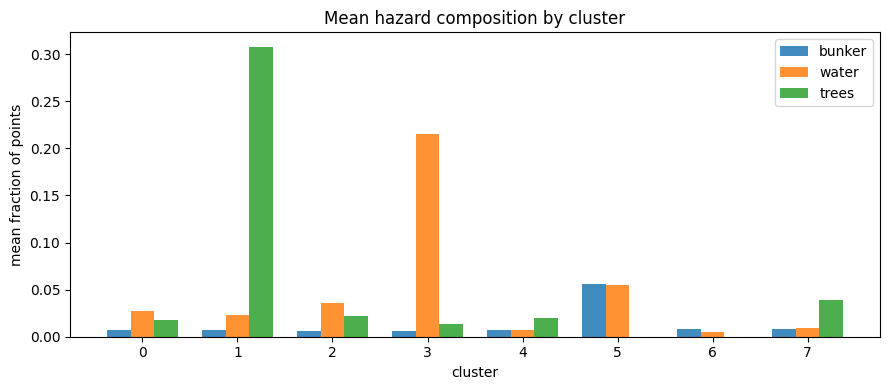

In [11]:
haz = prof[['bunker', 'water', 'trees']]
xpos = np.arange(len(haz)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
for i, c in enumerate(['bunker', 'water', 'trees']):
    ax.bar(xpos + (i - 1) * w, haz[c].values, width=w, label=c, alpha=0.85)
ax.set_xticks(xpos); ax.set_xticklabels(haz.index)
ax.set_ylabel('mean fraction of points'); ax.set_xlabel('cluster')
ax.set_title('Mean hazard composition by cluster'); ax.legend(); plt.tight_layout(); plt.show()

## 6. Find similar holes (v1)

`show_similar(hole_id, n, exclude_same_course, same_par)` recomputes v1 neighbors
live; the precomputed `hole_similarity_examples.csv` is the unrestricted view.

In [12]:
def show_similar(hole_id, n=10, exclude_same_course=False, same_par=False):
    out = similar_holes(feat, X, hole_id, k=n,
                        exclude_same_course=exclude_same_course, same_par=same_par)
    return out[['rank','similar_hole_id','similar_course_slug',
                'similar_hole_number','distance']].reset_index(drop=True)

def show_mode(hole_id, n=5, mode='cross_course_same_par_length_guarded'):
    out = similar_holes_mode(feat, cols, hole_id, mode, k=n)
    return out[['rank','similar_hole_id','similar_course_slug',
                'similar_hole_number','distance']].reset_index(drop=True)

def with_length(rows_df, hole_id):
    q = float(LEN_OF[hole_id])
    t = rows_df.copy()
    t['query_length_m'] = round(q, 1)
    t['similar_length_m'] = t['similar_hole_id'].map(LEN_OF).round(1)
    t['length_diff_m'] = (t['similar_length_m'] - q).abs().round(1)
    return t[['rank','similar_hole_id','query_length_m','similar_length_m','length_diff_m','distance']]

COMPARE_COLS = ['hole_length_m','par','fairway_pct','rough_pct','bunker_pct',
    'water_pct','trees_pct','dogleg_score','fairway_width_drive_zone',
    'fairway_width_approach_zone','green_complex_bunker_pct',
    'green_complex_water_pct','tee_to_green_elevation_change']

def compare_holes(query_hole_id, match_hole_id):
    sub = (feat[feat['hole_id'].isin([query_hole_id, match_hole_id])]
           .set_index('hole_id')[COMPARE_COLS].T)
    sub = sub[[query_hole_id, match_hole_id]]
    sub['abs_diff'] = (sub[query_hole_id] - sub[match_hole_id]).abs()
    return sub.round(3)

### Same-course bias check

In [13]:
nn10 = nearest_neighbor_table(feat, X, k=10)
same_frac = (nn10['query_course_slug'] == nn10['similar_course_slug']).mean()
print(f"Average share of SAME-course holes in each hole's top-10 v1 neighbors: {same_frac:.1%}")

Average share of SAME-course holes in each hole's top-10 v1 neighbors: 18.3%


## 7. v2 — length-aware similarity (recommended for presentation)

**Why this is needed.** In v1, `hole_length_m` is one standardized feature among
~86, so strategic shape, hazards, and elevation can outvote a big length gap. That
let Augusta #1 (~400 m) match a ~300 m hole — too different to call "similar" in
the main mode.

**v2** fixes this two ways (both preserve v1; see `SIMILARITY_MODES`):
1. **Feature weighting** — up-weight length-related features (`hole_length_m`,
   `green_y_m`, `hole_depth_m`, `par`) *after* standardization. (`hole_length_yd`
   is weighted 0 so length isn't double-counted.)
2. **Length guard** — drop candidates whose length differs from the query by more
   than `max(35 m, 12% of query length)`. A 400 m hole then allows ~48 m, not ~100 m.

Compare the three views for the same query (watch the `length_diff_m` column):

In [14]:
SAMPLE = 'augusta_national__01'
print(f'{SAMPLE} length = {float(LEN_OF[SAMPLE]):.0f} m\n')
print('(A) v1 unrestricted (any course, any par) -- DIAGNOSTIC ONLY:')
display(with_length(show_similar(SAMPLE, 5), SAMPLE))
print('(B) v1 same-par cross-course (no length guard):')
display(with_length(show_similar(SAMPLE, 5, exclude_same_course=True, same_par=True), SAMPLE))
print('(C) v2 length-aware, same-par, cross-course, length-guarded -- RECOMMENDED:')
display(with_length(show_mode(SAMPLE, 5, 'cross_course_same_par_length_guarded'), SAMPLE))

augusta_national__01 length = 409 m

(A) v1 unrestricted (any course, any par) -- DIAGNOSTIC ONLY:


,rank,similar_hole_id,query_length_m,similar_length_m,length_diff_m,distance
0,1,augusta_national__14,409.4,399.7,9.7,8.092740
1,2,augusta_national__03,409.4,315.0,94.4,10.165056
2,3,augusta_national__18,409.4,432.3,22.9,11.074746
3,4,augusta_national__08,409.4,522.6,113.2,11.358390
4,5,detroit_golf_club__14,409.4,455.6,46.2,11.527480


(B) v1 same-par cross-course (no length guard):


,rank,similar_hole_id,query_length_m,similar_length_m,length_diff_m,distance
0,1,tpc_deere_run__13,409.4,303.4,106.0,12.034133
1,2,tpc_deere_run__11,409.4,293.4,116.0,12.152429
2,3,harbour_town_golf_links__10,409.4,410.9,1.5,12.199949
3,4,detroit_golf_club__07,409.4,346.7,62.7,12.398848
4,5,tpc_deere_run__09,409.4,321.2,88.2,12.491035


(C) v2 length-aware, same-par, cross-course, length-guarded -- RECOMMENDED:


,rank,similar_hole_id,query_length_m,similar_length_m,length_diff_m,distance
0,1,harbour_town_golf_links__10,409.4,410.9,1.5,12.949052
1,2,spyglass_hill_golf_course__16,409.4,389.6,19.8,13.137886
2,3,tpc_deere_run__05,409.4,384.2,25.2,13.286501
3,4,memorial_park_golf_course__13,409.4,367.4,42.0,13.443976
4,5,spyglass_hill_golf_course__03,409.4,405.3,4.1,13.846153


Note how (A) and sometimes (B) include holes tens of metres shorter/longer,
while (C) keeps every match within the length guard. The recommended presentation
mode is **(C)**: `same_par=True, exclude_same_course=True, max_length_diff_m=35,
max_length_diff_pct=0.12, mode="length_weighted"` (bundled as
`cross_course_same_par_length_guarded`).

## 8. Visual validation: do the nearest neighbors actually look similar?

The **main comparison uses the v2 length-guarded matches** (section 7C), so the
holes are also length-comparable. All panels share x/y scale (tee at origin, green
up). Rough is subtle; fairway / green / tee / bunkers / water / trees stand out.

> **Data source note.** Visual comparisons need each hole's compact point cloud. In local mode every hole is available; from a *lite* HF artifact only the curated subset is, so `viz_compare` skips any hole it can't find (the default `augusta_national__01` query and its neighbours are included in the lite tier).

,rank,similar_hole_id,query_length_m,similar_length_m,length_diff_m,distance
0,1,harbour_town_golf_links__10,409.4,410.9,1.5,12.949052
1,2,spyglass_hill_golf_course__16,409.4,389.6,19.8,13.137886
2,3,tpc_deere_run__05,409.4,384.2,25.2,13.286501


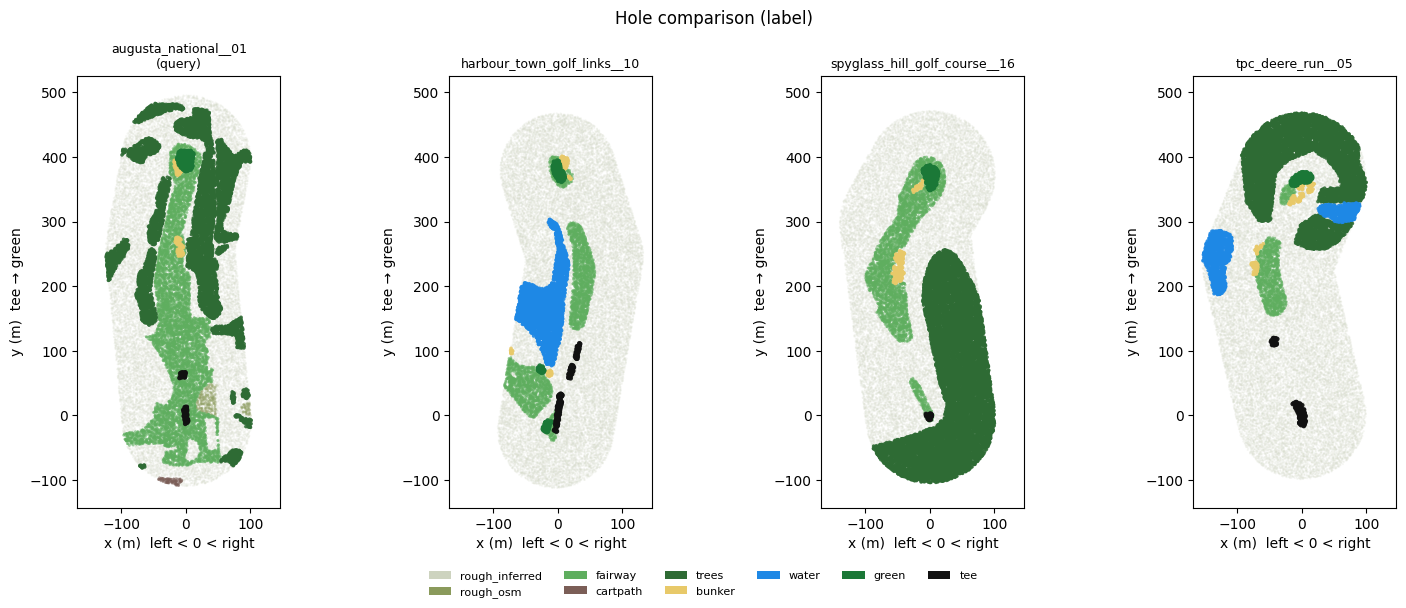

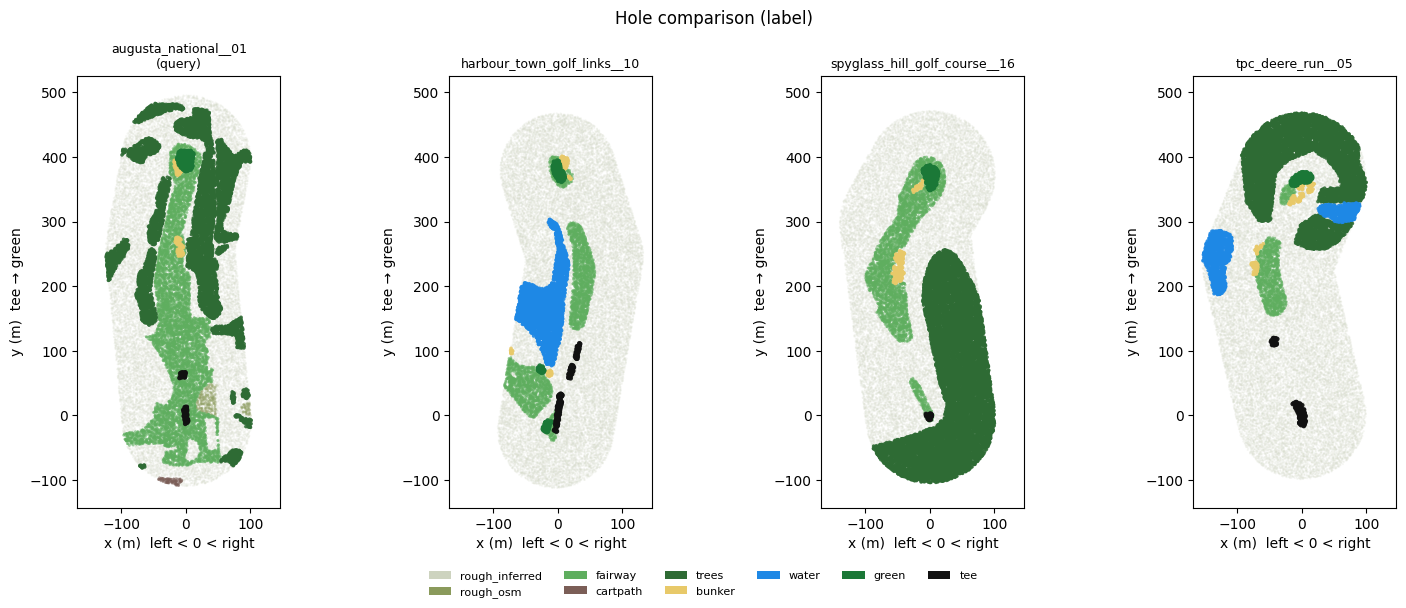

In [15]:
VQ = 'augusta_national__01'
v2_neighbors = show_mode(VQ, 3, 'cross_course_same_par_length_guarded')
display(with_length(v2_neighbors, VQ))
vids = [VQ] + list(v2_neighbors['similar_hole_id'])
vtitles = [f'{h}\n(query)' if h == VQ else h for h in vids]
# viz_compare handles both sources and skips holes missing from a lite artifact.
viz_compare(vids, titles=vtitles, color_by='label', max_points=30000)

**How to read it.** Shared axes mean a longer/wider corridor really is
longer/wider. With v2 the matches are length-comparable, so differences you see
are shape/hazard differences — not "this one is 100 m shorter." (The v1
unrestricted list in section 7A is a diagnostic and may include much shorter
holes; it is not the presentation result.)

Optional — the same holes colored by elevation relative to the tee:

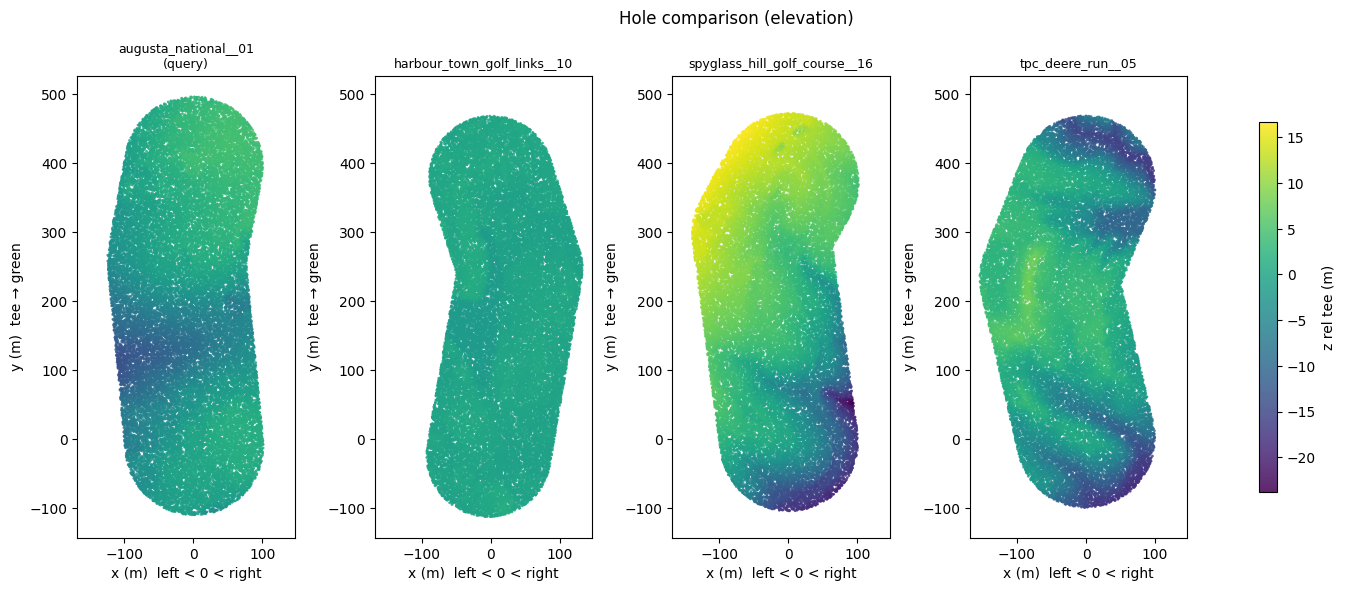

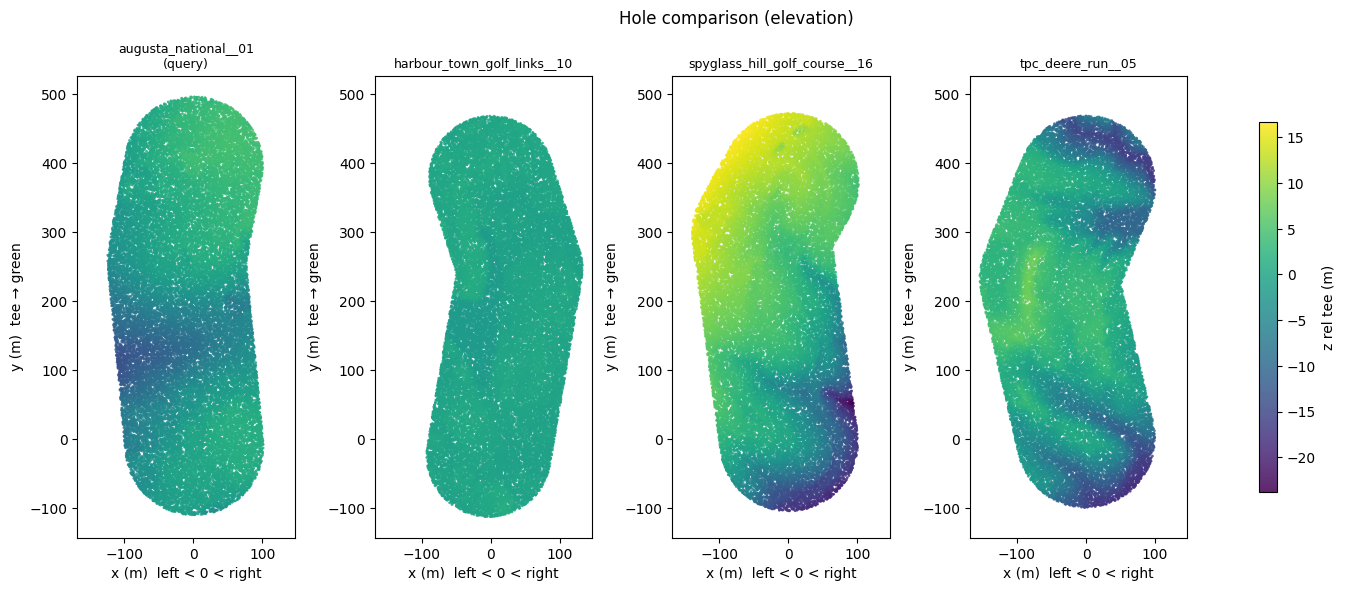

In [16]:
viz_compare(vids, titles=vtitles, color_by='elevation', max_points=30000)

In [17]:
# Save one sample v2 visual check (don't batch-generate hundreds).
# Local mode -> courses/_index/visual_checks/; HF-artifact mode -> ./visual_checks/.
if COMPACT_DIR is None:
    from pipeline.paths import IndexPaths
    vc_path = IndexPaths.for_root(COURSES_ROOT).visual_checks / f'{VQ}_v2_length_guarded.png'
else:
    vc_path = Path('visual_checks') / f'{VQ}_v2_length_guarded.png'
saved = viz_compare(vids, titles=vtitles, color_by='label', max_points=30000, save_to=vc_path)
if saved:
    print('saved', saved)

23:15:12 INFO    [golf.modeling.visual] saved hole comparison -> ..\courses\_index\visual_checks\augusta_national__01_v2_length_guarded.png


saved ..\courses\_index\visual_checks\augusta_national__01_v2_length_guarded.png


## 9. What the clusters mean (golf interpretation)

Read next to the **suggested_name** table (section 4):
- **`short_par_3__*`** — short, defended at the green complex.
- **`standard_par_4__*` / `long_standard_par_4__*`** — the bulk; split by hazard / dogleg.
- **`long_par_5__*`** — longest, biggest elevation range, widest fairways.
- **`*__tree_lined / water_heavy / bunker_heavy / dogleg / open_low_hazard`** — dominant character.

## 10. Limitations & recommended next steps

**Limitations:**
- **Point-cloud visualization, not imagery** — visual checks show labeled
  surfaces (what the model sees), not satellite/turf; a feature missing from OSM
  is missing from the plot.
- **Background dominance** — `rough_pct` reflects the wide corridor; consider
  hazard-weighted distance.
- **Same-course bias** — v1 top neighbors skew same-course (section 6); use
  `exclude_same_course=True`.
- **PCA is a 2D projection** — clustering/NN run on the full standardized space.
- **Engineered, not learned** — hand-built features encode our assumptions; v2
  weights and the length guard are deliberate, tunable choices.

**Next steps (later):**
- Tune v2 weights / guard per use case (e.g. "approach-similar" vs "tee-similar").
- A learned hole embedding from the raw point clouds.
- UMAP embedding (optional dependency) for non-linear structure.